# Chocolate Sales EDA

**Цель:** исследовать датасет продаж шоколада, выявить топ продажников/продуктов/стран, проанализировать динамику выручки и найти ключевые зависимости.

**Структура ноутбука:**
1. Загрузка и первичный осмотр
2. Очистка данных
3. Распределения переменных
4. Анализ по категориям
5. Корреляционный анализ
6. Динамика во времени
7. Разбор аномалий
8. Итоговые выводы

## 1. Загрузка и первичный осмотр

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('Chocolate Sales (2).csv')

print('Размер:', df.shape)
print('\nПервые строки:')
df.head()

Размер: (3282, 6)

Первые строки:


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [3]:
print('Типы данных и пропуски:')
df.info()
print('\nДубликатов:', df.duplicated().sum())
print('\nУникальных продажников:', df['Sales Person'].nunique())
print('Уникальных продуктов:', df['Product'].nunique())
print('Уникальных стран:', df['Country'].nunique())

Типы данных и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB

Дубликатов: 0

Уникальных продажников: 25
Уникальных продуктов: 22
Уникальных стран: 6


In [4]:
print('Базовая статистика (до очистки):')
df.describe(include='all')

Базовая статистика (до очистки):


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
count,3282,3282,3282,3282,3282,3282.000000
unique,25,6,22,504,3013,NaN
top,Kelci Walkden,Australia,50% Dark Bites,13/01/2024,"$2,317.00",NaN
freq,162,615,180,16,5,NaN
mean,NaN,NaN,NaN,NaN,NaN,164.666971
std,NaN,NaN,NaN,NaN,NaN,124.024736
min,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,71.000000
50%,NaN,NaN,NaN,NaN,NaN,137.000000
75%,NaN,NaN,NaN,NaN,NaN,232.000000


**Наблюдения после первичного осмотра:**
- `Amount` — тип object из-за символов `$` и запятых, требует очистки
- `Date` — тип object, нужна конвертация в datetime
- `Boxes Shipped` — единственный числовой столбец сразу
- Пропусков нет, дубликатов нет

## 2. Очистка данных

In [5]:
df_clean = df.copy()

# 1. Amount: убираем $ и запятые → float
df_clean['Amount'] = df_clean['Amount'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# 2. Date: конвертируем в datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], dayfirst=True)
df_clean['Month'] = df_clean['Date'].dt.to_period('M')
df_clean['Year'] = df_clean['Date'].dt.year

# 3. Price_per_Box: производный признак
df_clean['Price_per_Box'] = df_clean['Amount'] / df_clean['Boxes Shipped']

print('Типы после очистки:')
print(df_clean.dtypes)
print(f'\nДиапазон дат: {df_clean["Date"].min().date()} — {df_clean["Date"].max().date()}')

Типы после очистки:
Sales Person             object
Country                  object
Product                  object
Date             datetime64[ns]
Amount                  float64
Boxes Shipped             int64
Month                 period[M]
Year                      int32
Price_per_Box           float64
dtype: object

Диапазон дат: 2022-01-03 — 2024-08-31


**Что исправлено:**
- `Amount`: строка `"$5,320.00"` → число `5320.0`
- `Date`: строка → datetime, добавлены столбцы `Month` и `Year`
- Добавлен производный признак `Price_per_Box = Amount / Boxes Shipped`

## 3. Распределения переменных

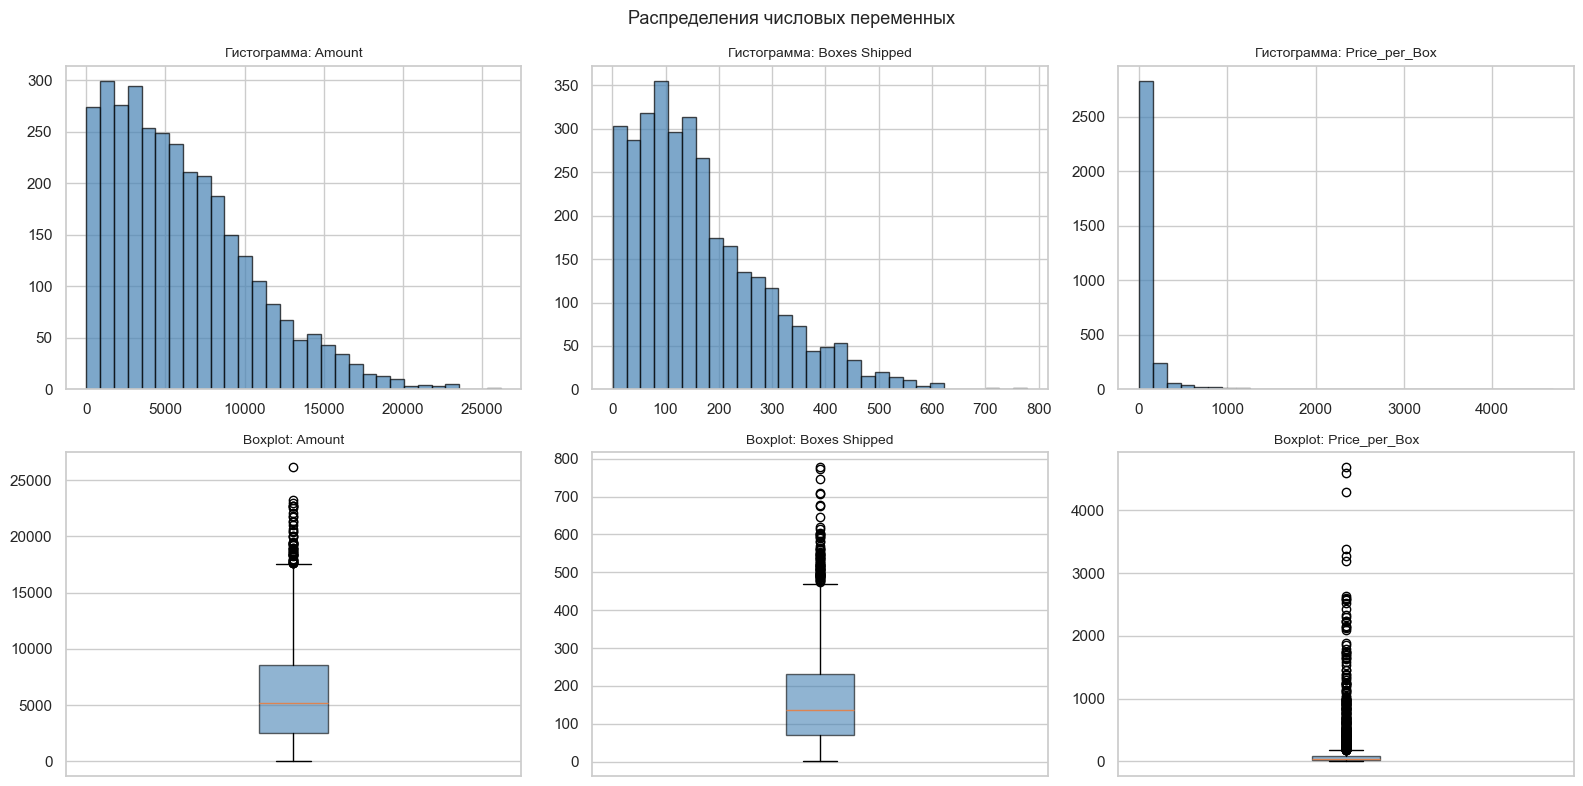

In [6]:
numeric_cols = ['Amount', 'Boxes Shipped', 'Price_per_Box']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, col in enumerate(numeric_cols):
    axes[0, i].hist(df_clean[col], bins=30, edgecolor='black', color='steelblue', alpha=0.7)
    axes[0, i].set_title(f'Гистограмма: {col}', fontsize=10)

    axes[1, i].boxplot(df_clean[col], patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1, i].set_title(f'Boxplot: {col}', fontsize=10)
    axes[1, i].set_xticks([])

plt.suptitle('Распределения числовых переменных', fontsize=13)
plt.tight_layout()
plt.show()

**Наблюдения:**
- `Amount` и `Boxes Shipped` — правосторонний скос, есть выбросы сверху
- Выбросы — реальные крупные заказы, **не ошибки данных** → не удаляем
- `Price_per_Box` — широкий разброс ($60–$250), что объясняет слабую корреляцию между коробками и выручкой

## 4. Анализ по категориям

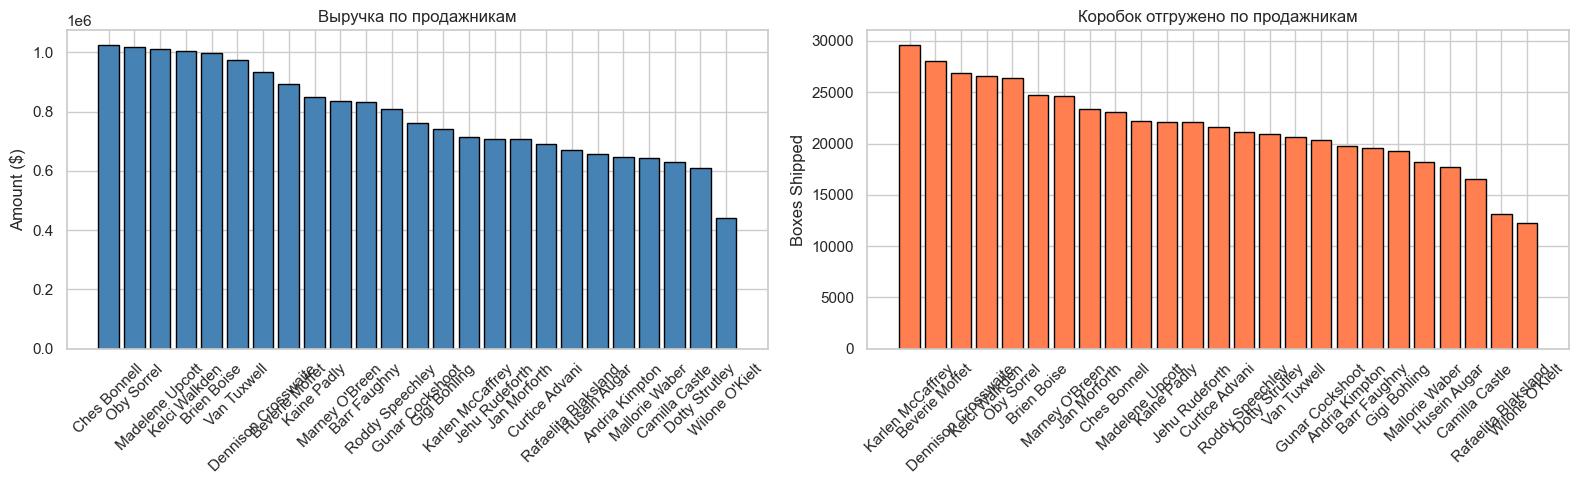

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Топ продажников по выручке
sales_by_person = df_clean.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False)
axes[0].bar(sales_by_person.index, sales_by_person.values, color='steelblue', edgecolor='black')
axes[0].set_title('Выручка по продажникам')
axes[0].set_ylabel('Amount ($)')
axes[0].tick_params(axis='x', rotation=45)

# Топ продажников по коробкам
boxes_by_person = df_clean.groupby('Sales Person')['Boxes Shipped'].sum().sort_values(ascending=False)
axes[1].bar(boxes_by_person.index, boxes_by_person.values, color='coral', edgecolor='black')
axes[1].set_title('Коробок отгружено по продажникам')
axes[1].set_ylabel('Boxes Shipped')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

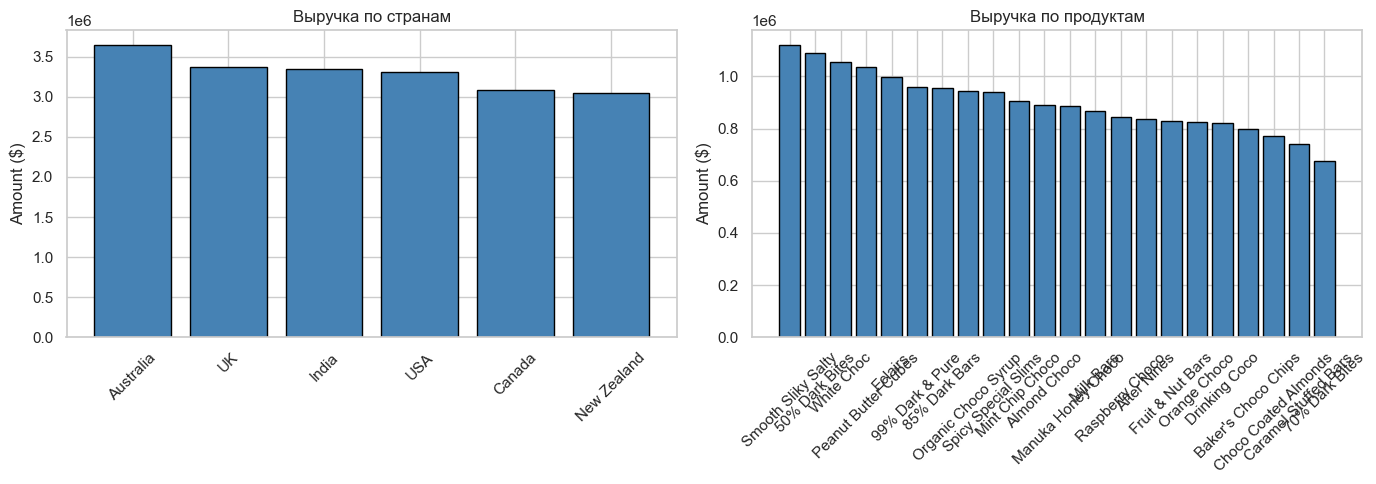

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Выручка по странам
sales_by_country = df_clean.groupby('Country')['Amount'].sum().sort_values(ascending=False)
axes[0].bar(sales_by_country.index, sales_by_country.values, color='steelblue', edgecolor='black')
axes[0].set_title('Выручка по странам')
axes[0].set_ylabel('Amount ($)')
axes[0].tick_params(axis='x', rotation=45)

# Выручка по продуктам
sales_by_product = df_clean.groupby('Product')['Amount'].sum().sort_values(ascending=False)
axes[1].bar(sales_by_product.index, sales_by_product.values, color='steelblue', edgecolor='black')
axes[1].set_title('Выручка по продуктам')
axes[1].set_ylabel('Amount ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

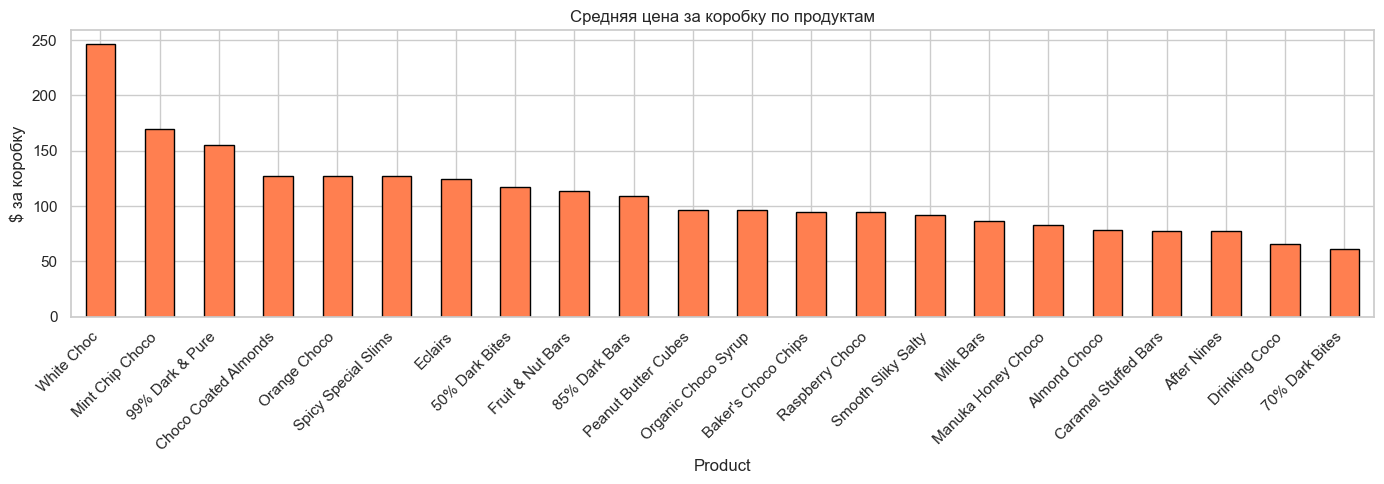

In [9]:
# Средняя цена за коробку по продуктам
avg_price = df_clean.groupby('Product')['Price_per_Box'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
avg_price.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Средняя цена за коробку по продуктам')
plt.ylabel('$ за коробку')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
# Топ-10 крупнейших сделок
top_deals = df_clean.nlargest(10, 'Amount')[['Sales Person', 'Country', 'Product', 'Amount', 'Boxes Shipped', 'Price_per_Box']]
print('Топ-10 крупнейших сделок:')
print(top_deals.to_string(index=False))

Топ-10 крупнейших сделок:
  Sales Person   Country             Product   Amount  Boxes Shipped  Price_per_Box
  Ches Bonnell     India Peanut Butter Cubes 26170.95            224     116.834598
  Ches Bonnell     India Peanut Butter Cubes 23251.68            210     110.722286
   Van Tuxwell Australia Organic Choco Syrup 22943.37             14    1638.812143
   Van Tuxwell     India Organic Choco Syrup 22751.18            182     125.006484
Curtice Advani     India  Smooth Sliky Salty 22717.09            143     158.860769
   Van Tuxwell     India Organic Choco Syrup 22701.85            168     135.130060
Marney O'Breen        UK  Smooth Sliky Salty 22558.88             84     268.558095
  Ches Bonnell     India Peanut Butter Cubes 22050.00            208     106.009615
   Kaine Padly        UK         After Nines 21812.86            183     119.195956
   Van Tuxwell Australia Organic Choco Syrup 21762.80             15    1450.853333


**Наблюдения по категориям:**
- Продажники: выручка распределена относительно равномерно — нет явного лидера
- Страны: все страны примерно одного уровня (синтетический датасет)
- Продукты: **White Choc** — самый дорогой (~$247/коробку), в 4× дороже 70% Dark Bites (~$60)
- Разброс цен $60–$247 объясняет слабую корреляцию между коробками и выручкой

## 5. Корреляционный анализ

Spearman (Amount vs Boxes Shipped): -0.017, p-value: 0.3403
Незначимо ❌ — корреляция случайная


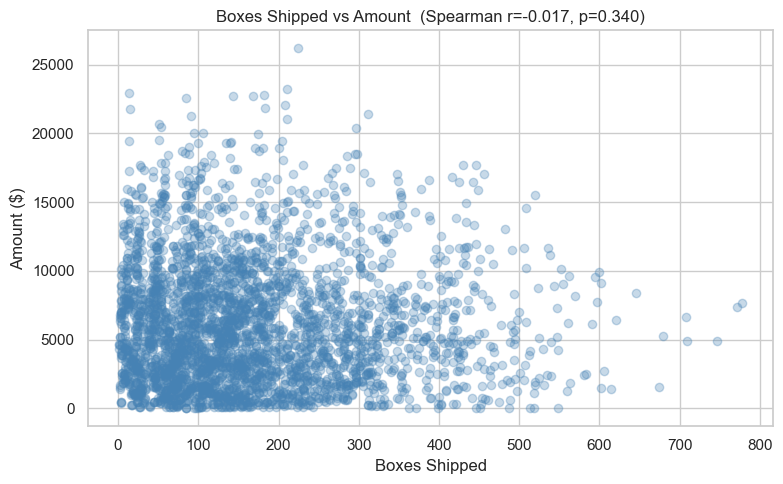

In [11]:
# Spearman — не требует нормального распределения
corr, p = spearmanr(df_clean['Amount'], df_clean['Boxes Shipped'])
print(f'Spearman (Amount vs Boxes Shipped): {corr:.3f}, p-value: {p:.4f}')
print('Значимо ✅' if p < 0.05 else 'Незначимо ❌ — корреляция случайная')

plt.figure(figsize=(8, 5))
plt.scatter(df_clean['Boxes Shipped'], df_clean['Amount'], alpha=0.3, color='steelblue')
plt.title(f'Boxes Shipped vs Amount  (Spearman r={corr:.3f}, p={p:.3f})')
plt.xlabel('Boxes Shipped')
plt.ylabel('Amount ($)')
plt.tight_layout()
plt.show()

**Результат корреляционного анализа:**
- Spearman r = -0.017, p-value = 0.34 → **связи между коробками и выручкой нет** ❌
- Причина: продукты имеют принципиально разную цену за коробку ($60–$247)
- Вывод: `Boxes Shipped` — плохой предиктор выручки. Нужно учитывать тип продукта

## 6. Динамика во времени

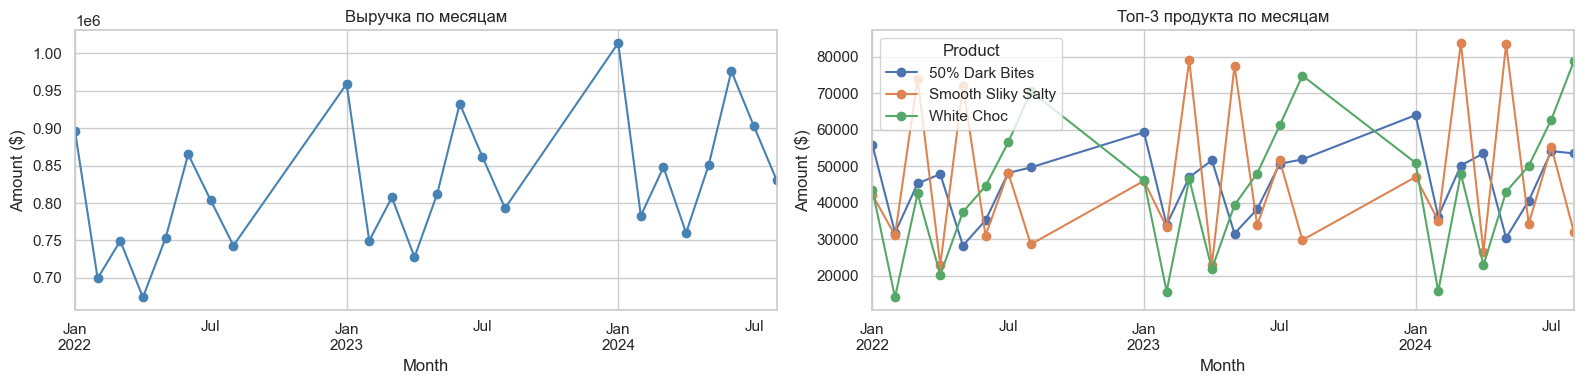

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Выручка по месяцам
monthly_amount = df_clean.groupby('Month')['Amount'].sum()
monthly_amount.plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Выручка по месяцам')
axes[0].set_ylabel('Amount ($)')
axes[0].grid(True)

# Топ-3 продукта по месяцам
top3 = df_clean.groupby('Product')['Amount'].sum().nlargest(3).index
df_clean[df_clean['Product'].isin(top3)].groupby(
    ['Month', 'Product'])['Amount'].sum().unstack().plot(ax=axes[1], marker='o')
axes[1].set_title('Топ-3 продукта по месяцам')
axes[1].set_ylabel('Amount ($)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Наблюдения по динамике:**
- Общий тренд **растущий**: выручка выросла с ~$0.7М (янв 2022) до пиков ~$1.0М (2024)
- Высокая волатильность: ежемесячные скачки ±20%
- Топ-3 продукта нестабильны — лидерство меняется каждый месяц
- **Январь 2024** — явный пик, требует дополнительного анализа

## 7. Разбор аномалий

In [13]:
# Январь 2024 — разбор пика выручки
jan_2024 = df_clean[df_clean['Month'] == '2024-01']
avg_month_deals = df_clean.groupby('Month').size().mean()

print('=== Январь 2024 ===')
print(f'Сделок: {len(jan_2024)} (среднее по месяцам: {avg_month_deals:.0f})')
print(f'Средний чек: ${jan_2024["Amount"].mean():.0f}')
print(f'Суммарная выручка: ${jan_2024["Amount"].sum():,.0f}')
print()
print('Топ-5 продуктов января 2024:')
print(jan_2024.groupby('Product')['Amount'].sum().sort_values(ascending=False).head(5))

=== Январь 2024 ===
Сделок: 154 (среднее по месяцам: 137)
Средний чек: $6582
Суммарная выручка: $1,013,622

Топ-5 продуктов января 2024:
Product
99% Dark & Pure        80582.76
Baker's Choco Chips    70200.63
Peanut Butter Cubes    66165.47
After Nines            64324.42
50% Dark Bites         63947.85
Name: Amount, dtype: float64


**Объяснение пика января 2024:**
- Сделок: **154 vs 137** в среднем (+12%) — пик создан объёмом, не размером сделок
- Средний чек стандартный (~$6,582)
- Необычный состав топ-продуктов: **99% Dark & Pure и Baker's Choco Chips** вместо привычных White Choc и Smooth Sliky Salty
- Возможная причина: сезонный сдвиг спроса (январь = здоровое питание после праздников)

## 8. Итоговые выводы

### Качество данных
- Пропусков нет, дубликатов нет
- Исправлено: `Amount` (строка → float), `Date` (строка → datetime)
- Добавлен производный признак `Price_per_Box`

### Ключевые находки
1. **Выручка растёт:** тренд с $0.7М до $1.0М за 2022–2024 при высокой ежемесячной волатильности
2. **Коробки не предсказывают выручку:** Spearman r = -0.017 (p=0.34) — связи нет
3. **Причина:** разброс цен в 4× ($60–$247/коробку) между продуктами полностью перекрывает объёмный эффект
4. **White Choc** — самый дорогой продукт (~$247/коробку), ключевой драйвер выручки
5. **Январь 2024** — пик выручки объяснён ростом числа сделок (+12%), не размером
6. **Сезонность спроса:** в январе аудитория смещается к "здоровым" продуктам

### Следующие шаги
- Построить модель прогнозирования выручки с учётом `Product` как ключевого фактора
- Исследовать причины высокой волатильности (сезонность, промо-акции?)
- Провести ABC-анализ продуктов и продажников